# Perfilado de Datos Crudos (Olist)

Análisis de calidad, tipos de datos y nulos inicial de las tablas crudas.

## 1. Importación de Librerías

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew

# Make the scripts package importable from this notebook's directory
sys.path.insert(0, str(Path(".").resolve()))

from scripts.data_loader import load_raw_datasets
from scripts.data_quality import (
    check_key_uniqueness,
    check_temporal_consistency,
    get_null_report,
    summarize_datasets,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="muted")

## 2. Carga de Datasets Crudos

In [ ]:
datasets = load_raw_datasets()

customers   = datasets["customers"]
orders      = datasets["orders"]
payments    = datasets["payments"]
reviews     = datasets["reviews"]
order_items = datasets["order_items"]
products    = datasets["products"]
sellers     = datasets["sellers"]

print("Los 7 datasets crudos fueron cargados correctamente.")

## 3. Exploración Inicial y Dimensiones

In [ ]:
display(summarize_datasets(datasets))

### Catálogos Auxiliares

Revisión rápida de productos y vendedores.

In [4]:
print("===== PRODUCTS HEAD =====")
display(products.head(3))
print("\n===== PRODUCTS INFO =====")
products.info()

print("\n===== SELLERS HEAD =====")
display(sellers.head(3))
print("\n===== SELLERS INFO =====")
sellers.info()

===== PRODUCTS HEAD =====


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



===== PRODUCTS INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

===== SELLERS HEAD =====


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



===== SELLERS INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


## 4. Análisis de Valores Nulos

In [ ]:
null_report = get_null_report(datasets)

for name, null_df in null_report.items():
    print(f"\n===== NULLS IN {name.upper()} =====")
    display(null_df)

for name in datasets:
    if name not in null_report:
        print(f"\n===== {name.upper()}: No contiene nulos =====")

### Visualización de Completitud

Patrón de datos faltantes en productos y reviews.

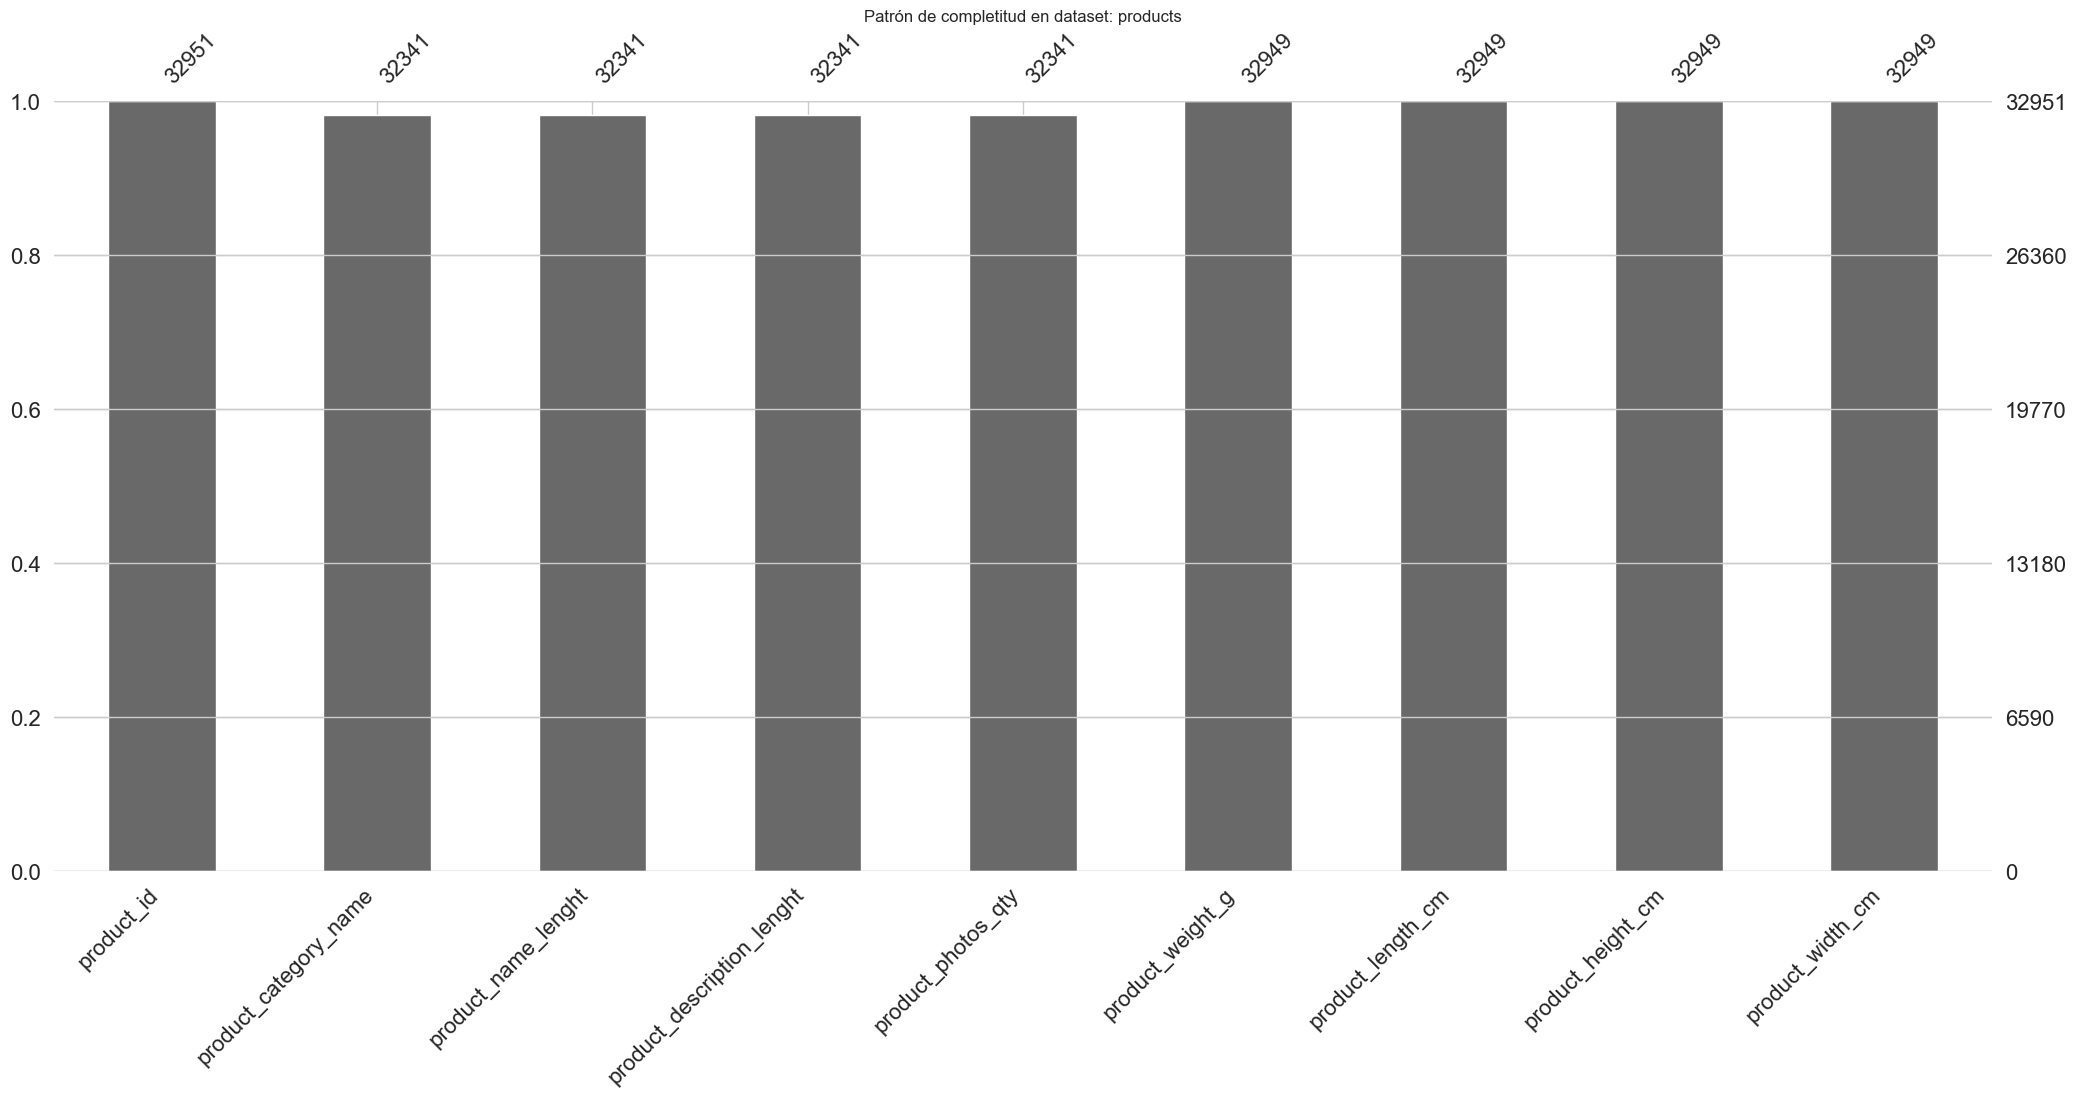

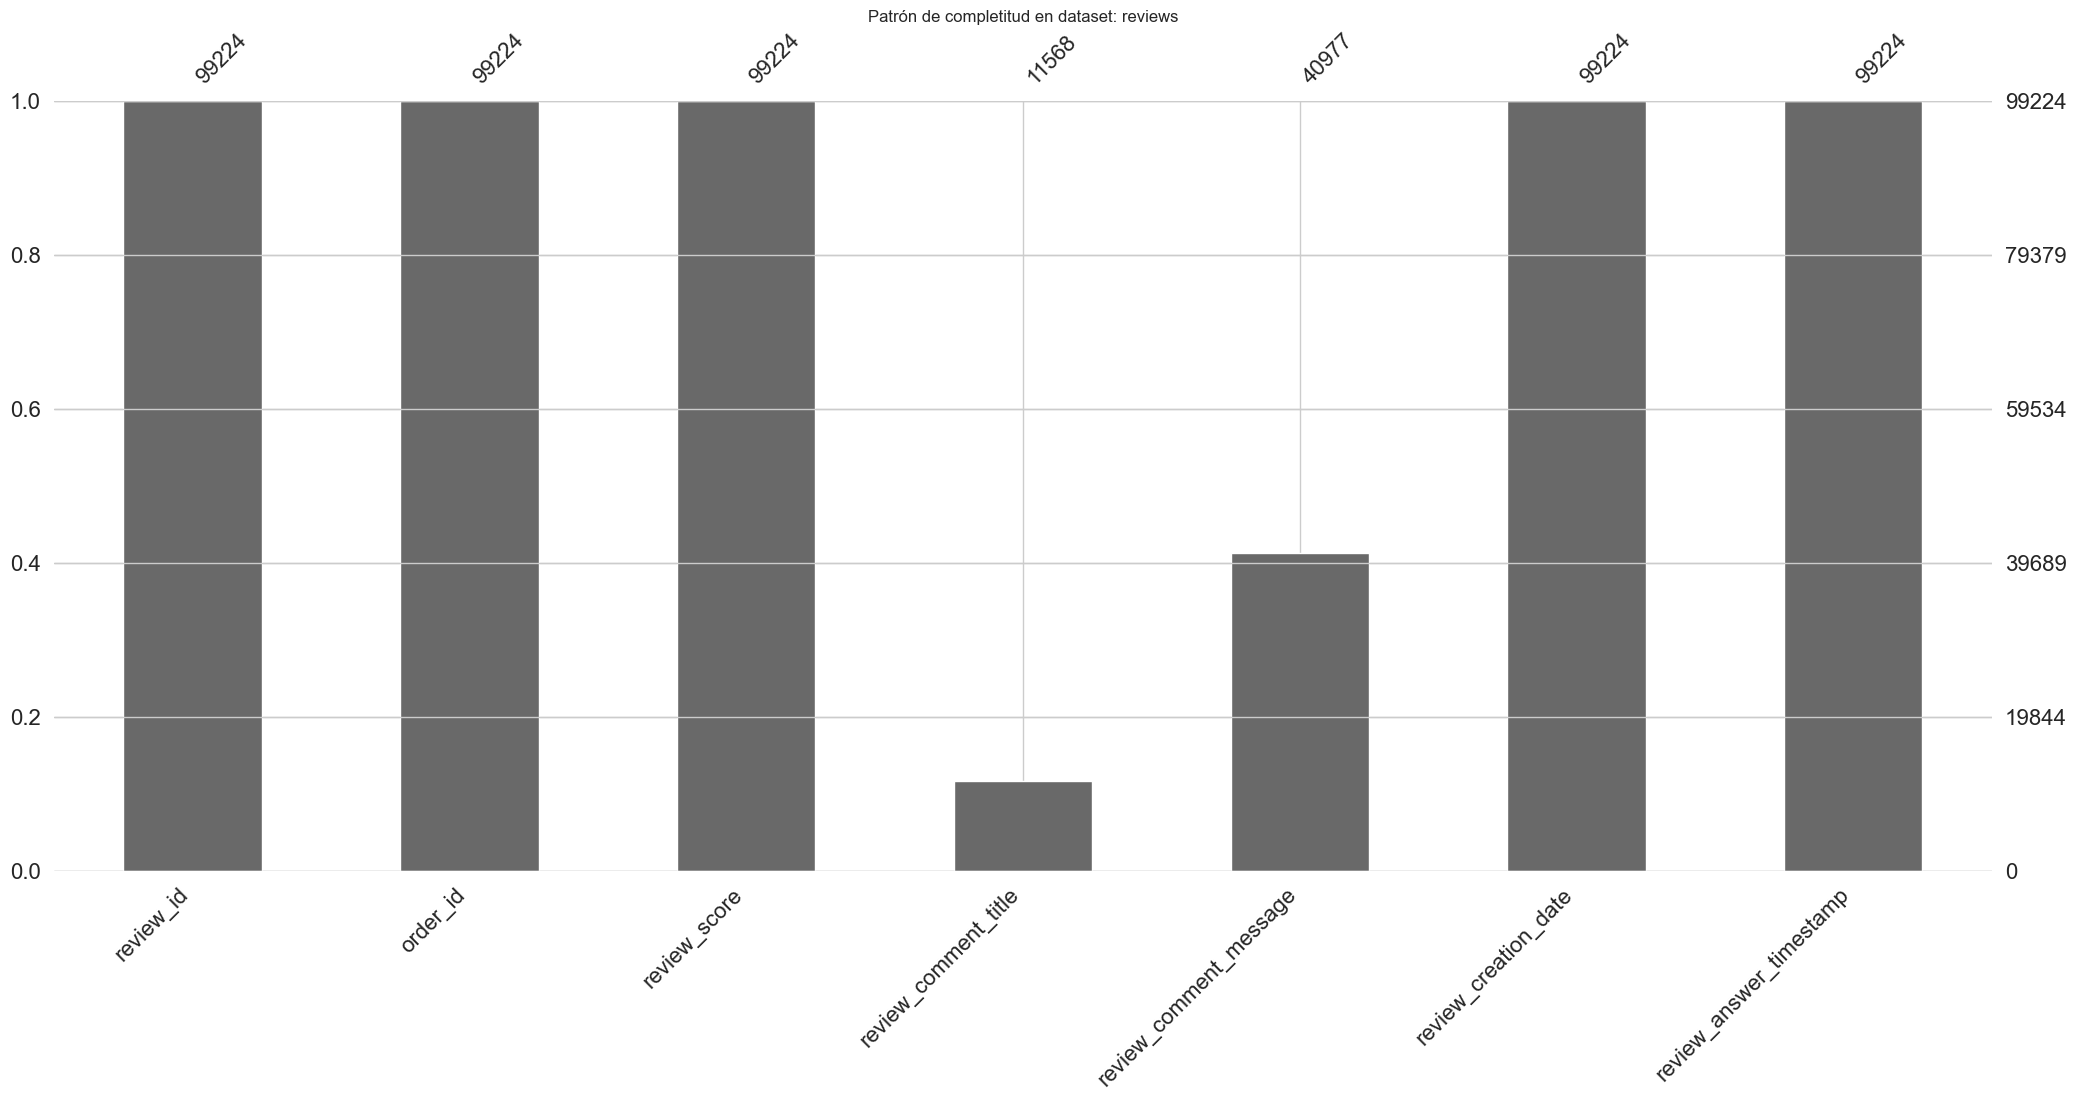

In [6]:
for name in ["products", "reviews"]:
    plt.figure(figsize=(10, 4))
    msno.bar(datasets[name])
    plt.title(f"Patrón de completitud en dataset: {name}")
    plt.show()

## 5. Integridad de Claves Primarias y Unicidad

In [ ]:
uniqueness = check_key_uniqueness(customers, orders, products, sellers, order_items)

print("===== Verificación de Unicidad de Claves =====")
for check, result in uniqueness.items():
    print(f"{check}: {result}")

## 6. Auditoría de Consistencia Temporal

Validación del ciclo lógico de fechas de envío y entrega.

In [ ]:
consistency = check_temporal_consistency(orders)

print("===== Reporte de Inconsistencias Temporales =====")
print(f"Pedidos con envío al transportista anterior a la compra:                {consistency['carrier_before_purchase']}")
print(f"Pedidos con recogida de transportista anterior a la aprobación de pago: {consistency['carrier_before_approved']}")
print(f"Pedidos entregados al cliente antes de recibirlos el transportista:     {consistency['delivered_before_carrier']}")
print(f"Pedidos entregados al cliente antes de la aprobación de pago:           {consistency['delivered_before_approved']}")

## 7. Distribución del Estado de Órdenes

,Órdenes,Proporción
order_status,,
delivered,96478,0.970203
shipped,1107,0.011132
canceled,625,0.006285
unavailable,609,0.006124
invoiced,314,0.003158
processing,301,0.003027
created,5,0.000050
approved,2,0.000020


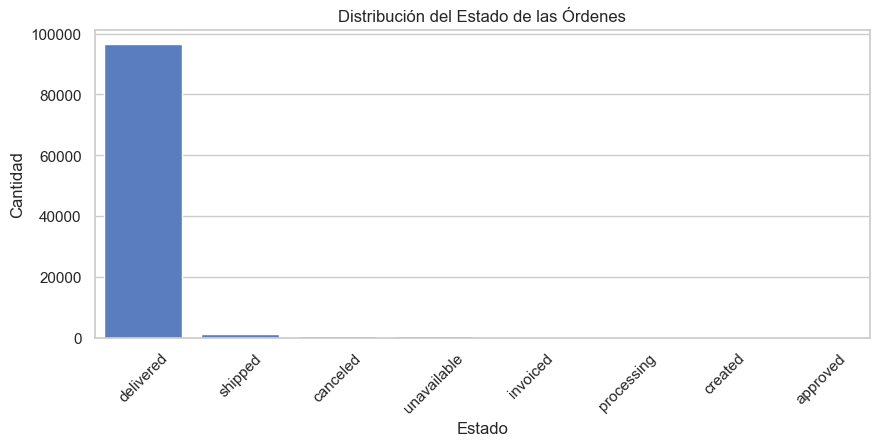

In [9]:
order_status_counts = orders["order_status"].value_counts()
order_status_props = orders["order_status"].value_counts(normalize=True)
display(pd.DataFrame({"Órdenes": order_status_counts, "Proporción": order_status_props}))

plt.figure(figsize=(10, 4))
sns.countplot(data=orders, x="order_status", order=order_status_counts.index)
plt.title("Distribución del Estado de las Órdenes")
plt.xlabel("Estado")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

## 8. Asimetría Financiera (Precios y Fletes)

Análisis de la distribución logarítmica de precios y fletes para justificar el uso de percentiles.

Asimetría (Skewness) de Precios: 7.9231
Asimetría (Skewness) de Fletes: 5.6398


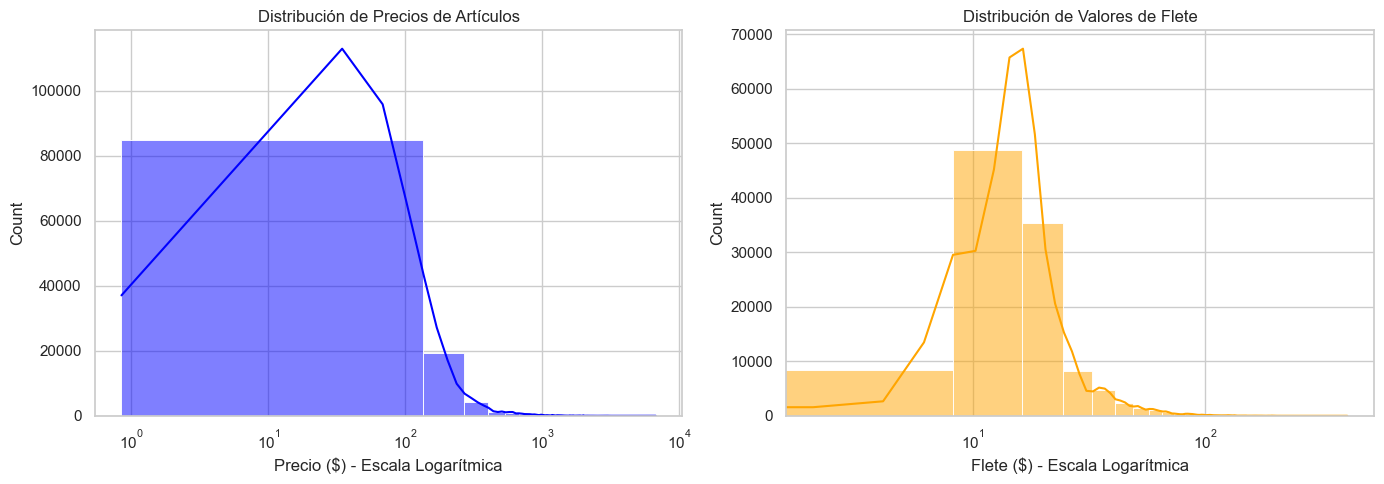

In [10]:
price_skew = skew(order_items["price"].dropna())
freight_skew = skew(order_items["freight_value"].dropna())

print(f"Asimetría (Skewness) de Precios: {price_skew:.4f}")
print(f"Asimetría (Skewness) de Fletes: {freight_skew:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de Precios
sns.histplot(data=order_items, x="price", kde=True, ax=axes[0], bins=50, color="blue")
axes[0].set_title("Distribución de Precios de Artículos")
axes[0].set_xlabel("Precio ($)")
axes[0].set_xscale("log")
axes[0].set_xlabel("Precio ($) - Escala Logarítmica")

# Histograma de Fletes
sns.histplot(data=order_items, x="freight_value", kde=True, ax=axes[1], bins=50, color="orange")
axes[1].set_title("Distribución de Valores de Flete")
axes[1].set_xlabel("Flete ($)")
axes[1].set_xscale("log")
axes[1].set_xlabel("Flete ($) - Escala Logarítmica")

plt.tight_layout()
plt.show()

### Conclusión sobre el Target:
La asimetría positiva extrema (>7) indica que el gasto está concentrado en una cola larga. Esto justifica usar un percentil robusto (percentil 80) para definir el target `is_premium`.

## 9. Detección de Anomalías Cuantitativas

Identificación de valores <= 0 en fletes y pagos.

In [11]:
print("===== Resumen de Variables Financieras =====")
display(order_items[["price", "freight_value"]].describe().T)
display(payments[["payment_value"]].describe().T)

print("\n===== Detección de Valores <= 0 =====")
print("Items con precio <= 0:", (order_items["price"] <= 0).sum())
print("Items con flete < 0:", (order_items["freight_value"] < 0).sum())
print("Pagos con valor <= 0:", (payments["payment_value"] <= 0).sum())

# investigar pagos con valor <= 0
if (payments["payment_value"] <= 0).sum() > 0:
    print("\nDetalle de pagos con valor <= 0 (Ejemplos de vouchers o cupones de descuento completo):")
    display(payments[payments["payment_value"] <= 0].head(5))

===== Resumen de Variables Financieras =====


,count,mean,std,min,25%,50%,75%,max
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68


,count,mean,std,min,25%,50%,75%,max
payment_value,103886.0,154.10038,217.494064,0.0,56.79,100.0,171.8375,13664.08



===== Detección de Valores <= 0 =====
Items con precio <= 0: 0
Items con flete < 0: 0
Pagos con valor <= 0: 9

Detalle de pagos con valor <= 0 (Ejemplos de vouchers o cupones de descuento completo):


,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
